# Exploratory Data Analysis

EDA for Arabic AI-Generated Text Detection (Task 2.3).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import arabic_reshaper
from bidi.algorithm import get_display

from src.utils import PROCESSED_DIR, FIGURES_DIR, ensure_dirs
from src.mapreduce_jobs import word_count_mr, bigram_count_mr, hapax_legomena_count

ensure_dirs()
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

FONT = os.path.abspath(os.path.join('..', 'Amiri-Regular.ttf'))
print('Font exists:', os.path.exists(FONT))

def ar(text):
    return get_display(arabic_reshaper.reshape(text))

def read_parquet_dir(path):
    if os.path.isdir(path):
        files = sorted([os.path.join(path, f) for f in os.listdir(path)
                        if f.endswith('.parquet') and not f.startswith('.') and not f.startswith('_')])
        return pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    return pd.read_parquet(path)

df = read_parquet_dir(os.path.join(PROCESSED_DIR, 'processed_abstracts.parquet'))
print(f'Total rows: {len(df)}')
print(df.columns.tolist())

Font exists: True
Total rows: 36525
['text', 'source', 'label', 'source_split', 'text_normalized', 'text_no_stop', 'text_stemmed']


## 1. Class distribution

   label  count             class
0      1  33533    Generated (AI)
1      0   2992  Original (Human)

By source:
   source  count
0  openai   8388
1   allam   8388
2    jais   8383
3   llama   8374
4   human   2992


C:\Users\Malru\AppData\Local\Temp\ipykernel_15764\1733345732.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(source_counts['source'], rotation=30)


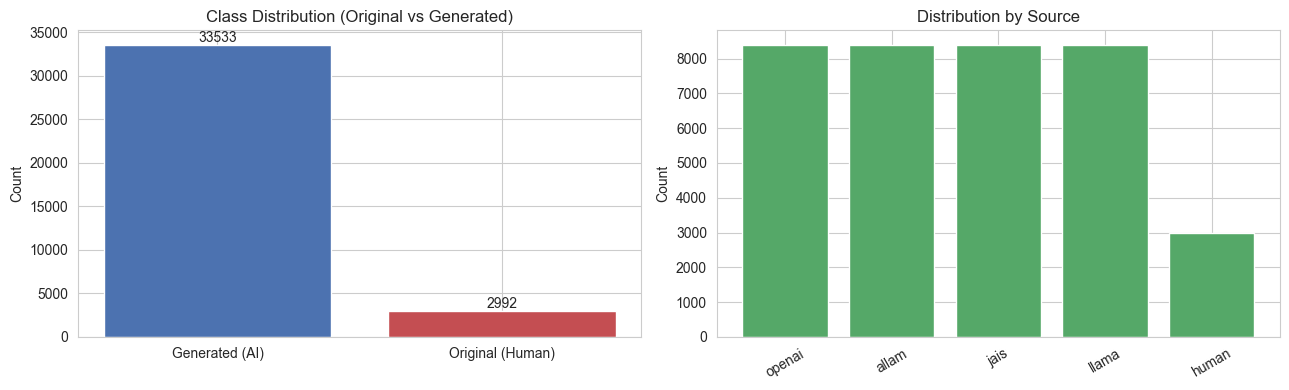

In [2]:
class_counts = df['label'].value_counts().reset_index()
class_counts.columns = ['label', 'count']
class_counts['class'] = class_counts['label'].map({0: 'Original (Human)', 1: 'Generated (AI)'})
print(class_counts)

source_counts = df['source'].value_counts().reset_index()
source_counts.columns = ['source', 'count']
print('\nBy source:')
print(source_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(class_counts['class'], class_counts['count'], color=['#4C72B0', '#C44E52'])
axes[0].set_title('Class Distribution (Original vs Generated)')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts['count']):
    axes[0].text(i, v + 300, str(v), ha='center')

axes[1].bar(source_counts['source'], source_counts['count'], color='#55A868')
axes[1].set_title('Distribution by Source')
axes[1].set_xticklabels(source_counts['source'], rotation=30)
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_01_class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2. Text length statistics

         char_len                          word_count                     
             mean         std  min    max        mean        std min   max
label                                                                     
0      739.980949  227.300376  411   1891  118.985294  36.794265  67   291
1      654.599529  261.515401  170  18459  101.140339  40.157748  27  2796


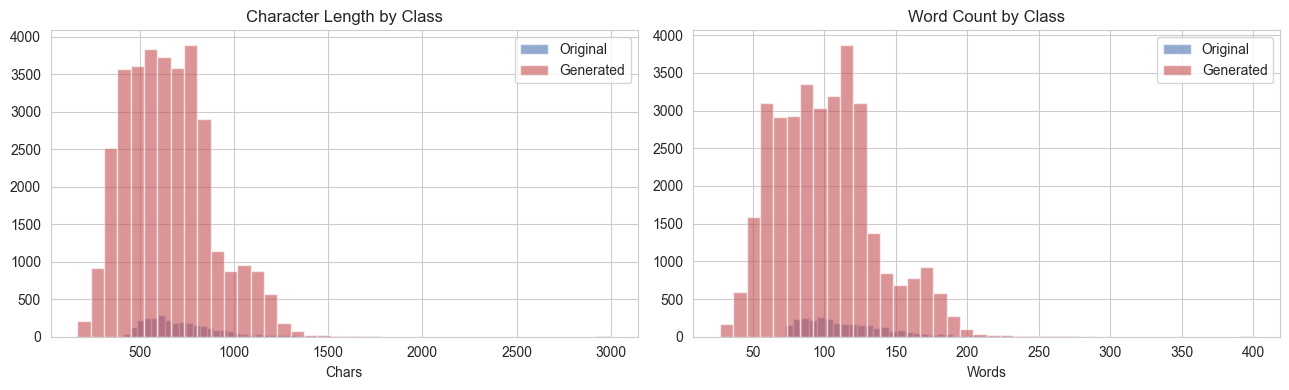

In [3]:
df['char_len'] = df['text'].astype(str).str.len()
df['word_count'] = df['text_normalized'].astype(str).str.split().str.len()
print(df.groupby('label')[['char_len', 'word_count']].agg(['mean', 'std', 'min', 'max']))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for lbl, name, color in [(0, 'Original', '#4C72B0'), (1, 'Generated', '#C44E52')]:
    sub = df[df.label == lbl]
    axes[0].hist(sub['char_len'].clip(upper=3000), bins=40, alpha=0.6, label=name, color=color)
    axes[1].hist(sub['word_count'].clip(upper=400), bins=40, alpha=0.6, label=name, color=color)
axes[0].set_title('Character Length by Class')
axes[0].set_xlabel('Chars'); axes[0].legend()
axes[1].set_title('Word Count by Class')
axes[1].set_xlabel('Words'); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_04_class_descriptive_stats.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Word clouds with Arabic font

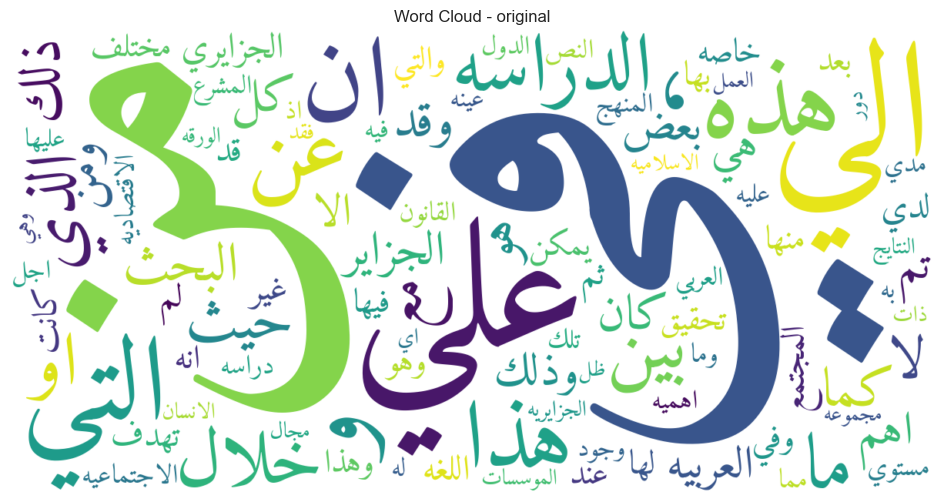

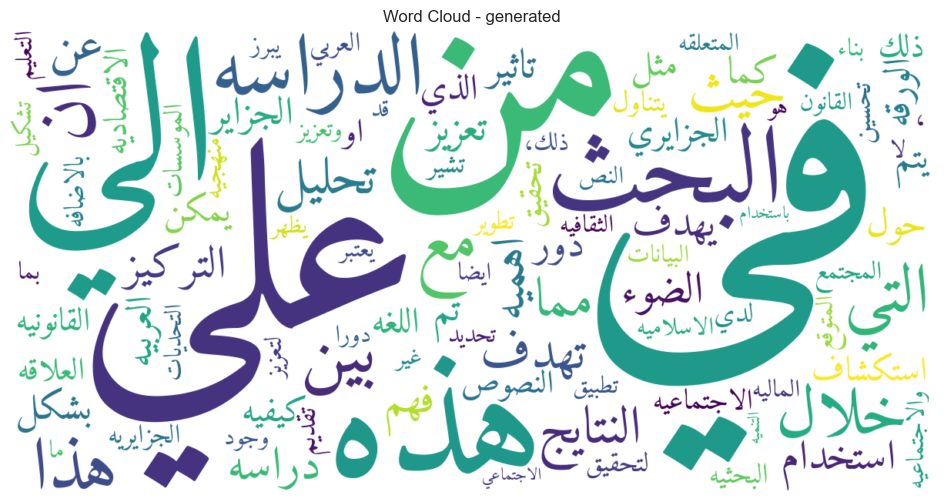

In [4]:
for lbl, name in [(0, 'original'), (1, 'generated')]:
    texts = df[df['label'] == lbl]['text_normalized'].tolist()
    wc_counter = word_count_mr(texts)
    top_raw = dict(wc_counter.most_common(100))
    top = {ar(w): c for w, c in top_raw.items()}
    try:
        wc = WordCloud(width=1200, height=600, background_color='white',
                       font_path=FONT, max_words=100).generate_from_frequencies(top)
        plt.figure(figsize=(13, 6))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Word Cloud - {name}')
        plt.savefig(os.path.join(FIGURES_DIR, f'fig_02_wordcloud_{name}.png'), dpi=150, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f'Failed for {name}: {e}')

## 4. Top bigrams

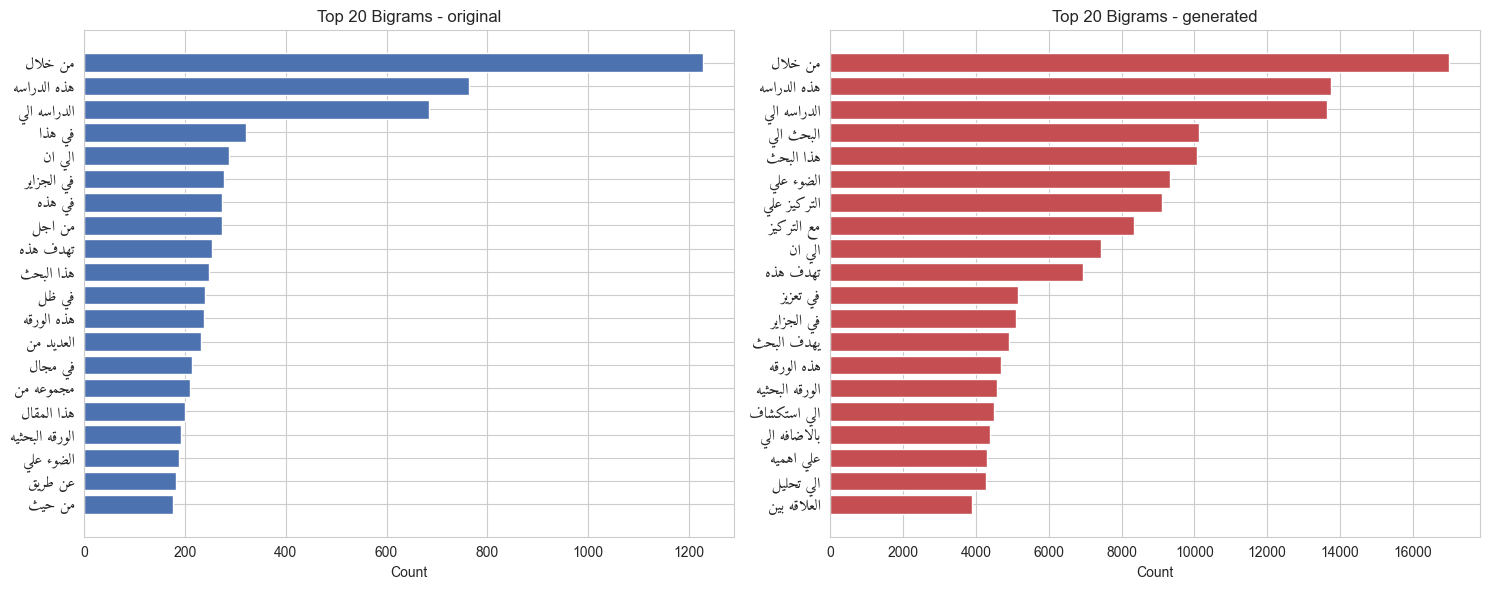

In [5]:
from matplotlib import font_manager
fp = font_manager.FontProperties(fname=FONT, size=11)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for i, (lbl, name) in enumerate([(0, 'original'), (1, 'generated')]):
    texts = df[df['label'] == lbl]['text_normalized'].tolist()
    bg = bigram_count_mr(texts).most_common(20)
    bigrams = [ar(b) for b, _ in bg]
    counts = [c for _, c in bg]
    axes[i].barh(range(len(bigrams)), counts, color='#4C72B0' if lbl == 0 else '#C44E52')
    axes[i].set_yticks(range(len(bigrams)))
    axes[i].set_yticklabels(bigrams, fontproperties=fp)
    axes[i].invert_yaxis()
    axes[i].set_title(f'Top 20 Bigrams - {name}')
    axes[i].set_xlabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_03_top_bigrams.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. TTR and Hapax Legomena

       class   tokens  types     TTR  hapax  hapax_ratio
0   Original   356004  53503  0.1503  30024       0.0843
1  Generated  3391539  86010  0.0254  31166       0.0092


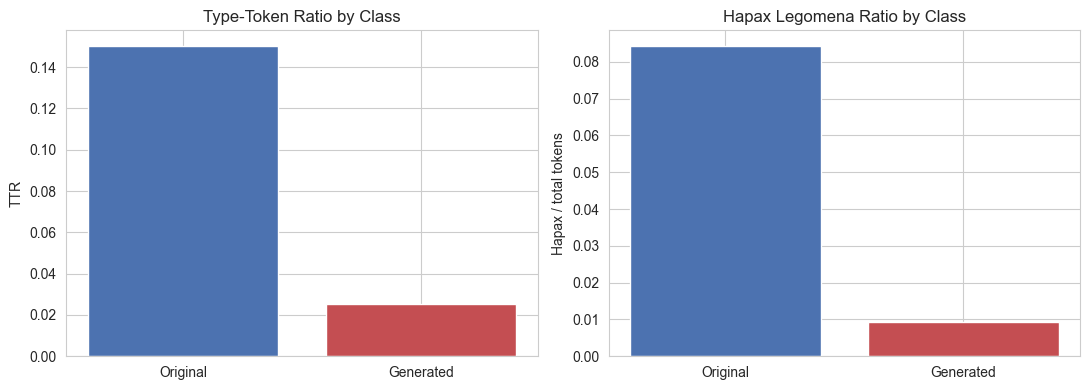

In [6]:
stats = []
for lbl, name in [(0, 'Original'), (1, 'Generated')]:
    texts = df[df['label'] == lbl]['text_normalized'].tolist()
    wc = word_count_mr(texts)
    total_types = len(wc)
    total_tokens = sum(wc.values())
    ttr = total_types / total_tokens if total_tokens > 0 else 0
    hapax_n, _, hapax_ratio = hapax_legomena_count(wc)
    stats.append({'class': name, 'tokens': total_tokens, 'types': total_types,
                  'TTR': round(ttr, 4), 'hapax': hapax_n, 'hapax_ratio': round(hapax_ratio, 4)})

stats_df = pd.DataFrame(stats)
print(stats_df)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(stats_df['class'], stats_df['TTR'], color=['#4C72B0', '#C44E52'])
axes[0].set_title('Type-Token Ratio by Class')
axes[0].set_ylabel('TTR')
axes[1].bar(stats_df['class'], stats_df['hapax_ratio'], color=['#4C72B0', '#C44E52'])
axes[1].set_title('Hapax Legomena Ratio by Class')
axes[1].set_ylabel('Hapax / total tokens')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_06_vocab_richness.png'), dpi=150, bbox_inches='tight')
plt.show()